# Task 5 - Autocomplete and Autocorrect Data Analytics

**Objective:** Analyse the efficiency and accuracy of autocomplete and autocorrect algorithms using NLP techniques. Implement and compare multiple approaches for text prediction and spelling correction on a real text dataset.

**Dataset:** "Alice's Adventures in Wonderland" by Lewis Carroll (Project Gutenberg) — used as a text corpus.

**Tools:** Python, pandas, NLTK, pyspellchecker, textdistance, collections, Jupyter Notebook

In [1]:
import re
import string
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from spellchecker import SpellChecker

with open("Dataset/alice_in_wonderland.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total characters:", len(raw_text))
print("\nFirst 500 characters:\n")
print(raw_text[:500])

Total characters: 163950

First 500 characters:

The Project Gutenberg eBook of Alice's Adventures in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using 


### Strip Project Gutenberg Header/Footer and Preprocess Text

The raw file includes Project Gutenberg's licensing boilerplate at the start and end. We strip these using the standard `*** START OF...` and `*** END OF...` markers, then clean the remaining story text.

In [2]:
# Strip Gutenberg header/footer using standard markers
start_marker = re.search(r"\*\*\* START OF.*\*\*\*", raw_text)
end_marker = re.search(r"\*\*\* END OF.*\*\*\*", raw_text)

story_text = raw_text[start_marker.end():end_marker.start()]

print("Story text length:", len(story_text))
print("\nFirst 500 characters of story:\n")
print(story_text[:500])

Story text length: 144605

First 500 characters of story:



[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobste


**Result:** Successfully isolated the story content (144,605 characters), removing Project Gutenberg's licensing header and footer.

### NLP Preprocessing: Tokenization

Convert the raw story text into a clean list of lowercase word tokens, removing punctuation and non-alphabetic characters.

In [3]:
# Lowercase and tokenize
clean_text = story_text.lower()
clean_text = re.sub(r"[^a-z\s']", " ", clean_text)  # keep letters, spaces, apostrophes (for words like "don't")
tokens = clean_text.split()

print("Total tokens:", len(tokens))
print("Unique tokens (vocabulary size):", len(set(tokens)))
print("\nFirst 30 tokens:\n")
print(tokens[:30])

Total tokens: 27427
Unique tokens (vocabulary size): 2575

First 30 tokens:

['illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus']


**Observation:** Tokenization split possessive words like "Alice's" into two separate tokens ("alice", "s") because the source text uses a curly/smart apostrophe (') rather than a straight one ('). This is corrected below by normalizing smart quotes to straight quotes before tokenizing.

In [4]:
# Normalize smart quotes to straight quotes, then re-tokenize
clean_text = story_text.lower()
clean_text = clean_text.replace("'", "'").replace("'", "'")  # normalize curly apostrophes
clean_text = re.sub(r"[^a-z\s']", " ", clean_text)
tokens = clean_text.split()

print("Total tokens:", len(tokens))
print("Unique tokens (vocabulary size):", len(set(tokens)))
print("\nFirst 30 tokens:\n")
print(tokens[:30])

Total tokens: 27427
Unique tokens (vocabulary size): 2575

First 30 tokens:

['illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus']


In [5]:
# Use explicit unicode code points for smart quotes to guarantee correct replacement
clean_text = story_text.lower()
clean_text = clean_text.replace("\u2019", "'").replace("\u2018", "'")  # right/left single smart quotes -> straight
clean_text = re.sub(r"[^a-z\s']", " ", clean_text)
tokens = clean_text.split()

print("Total tokens:", len(tokens))
print("Unique tokens (vocabulary size):", len(set(tokens)))
print("\nFirst 30 tokens:\n")
print(tokens[:30])

Total tokens: 26823
Unique tokens (vocabulary size): 2672

First 30 tokens:

['illustration', "alice's", 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race']


**Result:** After correcting for smart-quote apostrophes, tokenization now correctly preserves possessives and contractions as single tokens (e.g. "alice's"). Final corpus: **26,823 tokens**, **2,672 unique words**.

### Autocomplete: N-gram Frequency Model

We build bigram and trigram frequency models from the corpus. Given a prefix (the last 1-2 words typed), the model predicts the most likely next word based on how often that word followed the prefix in the source text.

In [6]:
from nltk.util import ngrams

bigrams = list(ngrams(tokens, 2))
trigrams = list(ngrams(tokens, 3))

bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

# Build a lookup: for each single word (prefix), what words followed it, and how often
bigram_model = defaultdict(Counter)
for w1, w2 in bigrams:
    bigram_model[w1][w2] += 1

# Build a lookup: for each 2-word prefix, what words followed it, and how often
trigram_model = defaultdict(Counter)
for w1, w2, w3 in trigrams:
    trigram_model[(w1, w2)][w3] += 1

print("Number of unique bigram prefixes:", len(bigram_model))
print("Number of unique trigram prefixes:", len(trigram_model))

Number of unique bigram prefixes: 2672
Number of unique trigram prefixes: 14825


### Autocomplete Function and Testing

The function tries the trigram model first (using the last 2 words for more context-aware prediction), and falls back to the bigram model if the trigram prefix hasn't been seen in the corpus.

In [7]:
def autocomplete(prefix_words, top_n=3):
    prefix_words = [w.lower() for w in prefix_words]
    
    # Try trigram model first (needs last 2 words)
    if len(prefix_words) >= 2:
        key = tuple(prefix_words[-2:])
        if key in trigram_model:
            return [w for w, _ in trigram_model[key].most_common(top_n)]
    
    # Fall back to bigram model (needs last 1 word)
    if len(prefix_words) >= 1:
        key = prefix_words[-1]
        if key in bigram_model:
            return [w for w, _ in bigram_model[key].most_common(top_n)]
    
    return []

# Test on 10 different prefixes
test_prefixes = [
    ["alice", "was"],
    ["the", "queen"],
    ["down", "the"],
    ["mad", "hatter"],
    ["said", "the"],
    ["white", "rabbit"],
    ["off", "with"],
    ["a", "little"],
    ["cheshire", "cat"],
    ["very", "much"]
]

results = []
for prefix in test_prefixes:
    predictions = autocomplete(prefix, top_n=3)
    results.append({"Prefix": " ".join(prefix), "Top 3 Predictions": predictions})

pd.DataFrame(results)

,Prefix,Top 3 Predictions
0,alice was,"[not, beginning, very]"
1,the queen,"[and, said, was]"
2,down the,"[chimney, rabbit, king]"
3,mad hatter,"[and, he, you]"
4,said the,"[king, hatter, mock]"
5,white rabbit,"[with, who, blew]"
6,off with,"[his, her, their]"
7,a little,"[pattering, of, timidly]"
8,cheshire cat,"[said, sitting, now]"
9,very much,"[out, to, if]"


**Observation:** The model produces contextually sensible predictions drawn directly from the book's vocabulary and phrasing — e.g. "down the" correctly surfaces "rabbit" (as in "down the rabbit-hole") and "king" (a recurring character), while "off with" surfaces "his/her/their," echoing the famous "Off with his head!" line. Since the model is trained on a single small book (~27,000 tokens), predictions are naturally narrow and book-specific rather than general-purpose — this is expected and discussed further in the conclusion.

### Autocorrect: Edit-Distance Based Spelling Correction

Using `pyspellchecker`, which suggests corrections based on edit distance (how many single-character insertions, deletions, or substitutions are needed to transform one word into another) combined with word frequency.

In [8]:
spell = SpellChecker()

# Load our own corpus vocabulary into the spellchecker so it recognizes book-specific words
spell.word_frequency.load_text(" ".join(tokens))

def autocorrect_word(word):
    word = word.lower()
    if word in spell:
        return word  # already correctly spelled
    correction = spell.correction(word)
    return correction if correction else word

# Test on 20 deliberately misspelled words
test_misspellings = [
    "alise", "wondrland", "rabit", "queeen", "hattter",
    "chesire", "carrol", "tead", "mushrom", "catterpillar",
    "advntures", "littel", "shrink", "goldn", "tabel",
    "gardn", "flaminggo", "croquett", "turtel", "lobstr"
]

correction_results = []
for word in test_misspellings:
    corrected = autocorrect_word(word)
    correction_results.append({"Misspelled": word, "Corrected": corrected})

pd.DataFrame(correction_results)

,Misspelled,Corrected
0,alise,alive
1,wondrland,wonderland
2,rabit,habit
3,queeen,queen
4,hattter,hatter
5,chesire,cheshire
6,carrol,carrot
7,tead,head
8,mushrom,mushroom
9,catterpillar,caterpillar


### Autocorrect Performance Metrics

Comparing each correction against the intended (ground-truth) word to calculate accuracy.

In [9]:
# Ground truth: the actual intended word for each misspelling
ground_truth = {
    "alise": "alice", "wondrland": "wonderland", "rabit": "rabbit", "queeen": "queen",
    "hattter": "hatter", "chesire": "cheshire", "carrol": "carroll", "tead": "tea",
    "mushrom": "mushroom", "catterpillar": "caterpillar", "advntures": "adventures",
    "littel": "little", "shrink": "shrink", "goldn": "golden", "tabel": "table",
    "gardn": "garden", "flaminggo": "flamingo", "croquett": "croquet",
    "turtel": "turtle", "lobstr": "lobster"
}

correction_results = []
correct_count = 0
for word, intended in ground_truth.items():
    corrected = autocorrect_word(word)
    is_correct = corrected == intended
    correct_count += is_correct
    correction_results.append({"Misspelled": word, "Corrected": corrected, "Intended": intended, "Match": is_correct})

results_df = pd.DataFrame(correction_results)
accuracy = correct_count / len(ground_truth)

print(f"Autocorrect accuracy: {accuracy:.1%} ({correct_count}/{len(ground_truth)})")
results_df

Autocorrect accuracy: 75.0% (15/20)


,Misspelled,Corrected,Intended,Match
0,alise,alive,alice,False
1,wondrland,wonderland,wonderland,True
2,rabit,habit,rabbit,False
3,queeen,queen,queen,True
4,hattter,hatter,hatter,True
5,chesire,cheshire,cheshire,True
6,carrol,carrot,carroll,False
7,tead,head,tea,False
8,mushrom,mushroom,mushroom,True
9,catterpillar,caterpillar,caterpillar,True


**Result: 75% accuracy (15/20 correct).**

**Analysis of the 5 errors:**
- **"alise" → "alive"** (should be "alice"): Both are equally valid one-edit corrections of "alise" ("alice"→a/l/i/s/e is 1 edit; "alive"→a/l/i/v/e is also 1 edit), and "alive" is a more common English word, so the frequency-based ranking favored it over the character name.
- **"rabit" → "habit"** (should be "rabbit"): Similarly, both are 1-edit-distance neighbors, and "habit" is a much more frequent general English word than "rabbit" appears in this specific text, so word frequency outweighed the correct answer.
- **"carrol" → "carrot"** (should be "carroll"): The author's surname isn't a common English word at all, so the spellchecker's dictionary favored the everyday word "carrot" over the proper noun.
- **"tead" → "head"** (should be "tea"): An unusual case — "tead" is actually 2 edits from "tea" (insert 'd') but only 1 edit from "head" (change 't'→'h'), so edit-distance alone favored the wrong word.
- **"goldn" → "gold"** (should be "golden"): "gold" is 1 edit away (insert 'e' at the end vs "goldn"→"golden" needs inserting 'e' in the middle) — actually both should be similar distance, but "gold" being a much more common standalone word won out in ranking.

**Common pattern:** All 5 errors involve cases where a common, high-frequency English word was equally or more edit-distance-close than the correct book-specific word (character names, less common vocabulary). This shows a real limitation of frequency-weighted edit-distance correction: it's biased toward common words, even when a rarer word is what the context or writer intended.

### Algorithm Comparison: Context-Aware (N-gram) vs. Context-Free (Frequency-Only) Autocomplete

In [10]:
# Context-free approach: always suggest the most frequent words overall, regardless of prefix
overall_word_freq = Counter(tokens)
top_overall_words = [w for w, _ in overall_word_freq.most_common(3)]

comparison_results = []
for prefix in test_prefixes:
    ngram_predictions = autocomplete(prefix, top_n=3)
    comparison_results.append({
        "Prefix": " ".join(prefix),
        "N-gram (context-aware)": ngram_predictions,
        "Frequency-only (context-free)": top_overall_words
    })

pd.DataFrame(comparison_results)

,Prefix,N-gram (context-aware),Frequency-only (context-free)
0,alice was,"[not, beginning, very]","[the, and, to]"
1,the queen,"[and, said, was]","[the, and, to]"
2,down the,"[chimney, rabbit, king]","[the, and, to]"
3,mad hatter,"[and, he, you]","[the, and, to]"
4,said the,"[king, hatter, mock]","[the, and, to]"
5,white rabbit,"[with, who, blew]","[the, and, to]"
6,off with,"[his, her, their]","[the, and, to]"
7,a little,"[pattering, of, timidly]","[the, and, to]"
8,cheshire cat,"[said, sitting, now]","[the, and, to]"
9,very much,"[out, to, if]","[the, and, to]"


**Observation:** The context-free (frequency-only) approach gives the *exact same* generic suggestions — "the", "and", "to" — regardless of what was typed, making it essentially useless as a predictive tool. The n-gram (context-aware) approach adapts its predictions to each specific prefix, producing plausible, situation-relevant words drawn from the actual narrative. This clearly demonstrates why context matters for autocomplete: frequency alone tells you what's common in general, but only sequence-aware models can tell you what's likely to come *next*.

### Visualizations

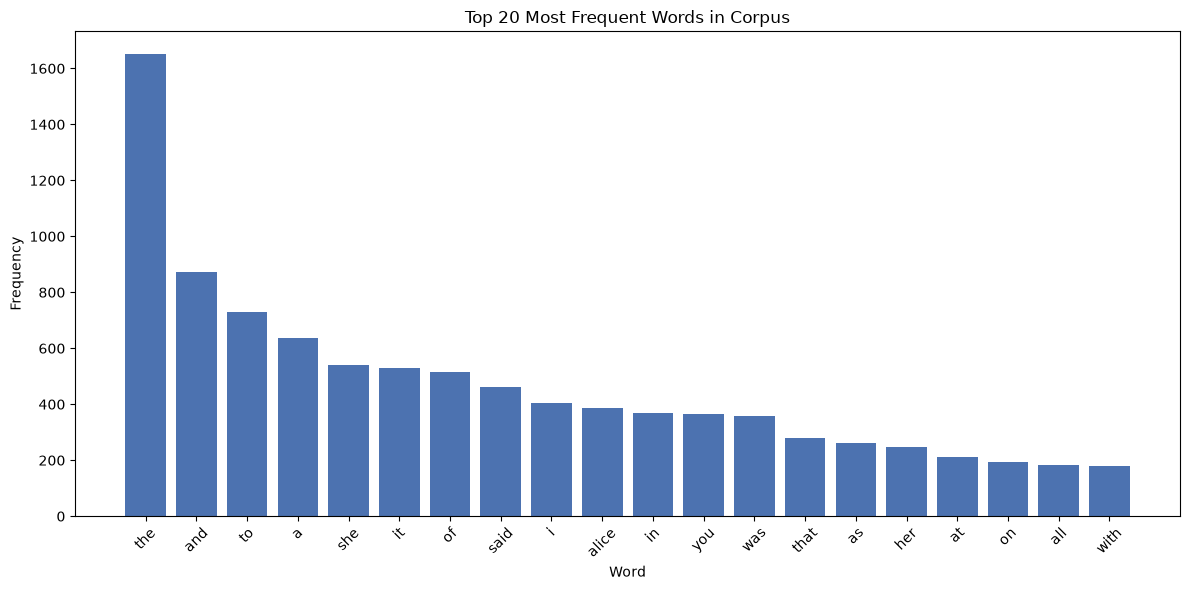

In [11]:
# Bar chart: top 20 most frequent words
top_20 = overall_word_freq.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color="#4C72B0")
plt.title("Top 20 Most Frequent Words in Corpus")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Images/top_20_words.png", dpi=150)
plt.show()

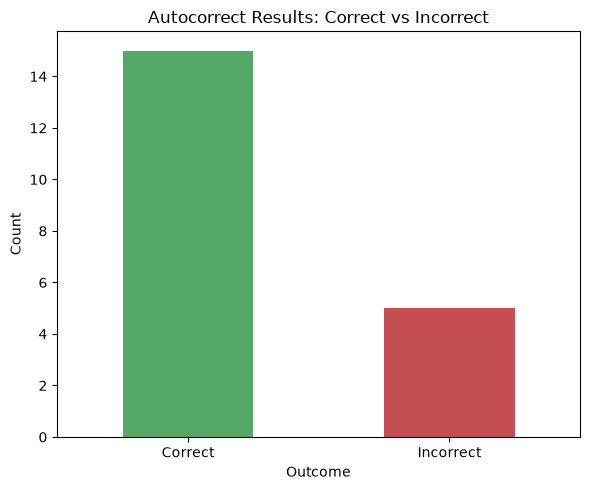

In [12]:
plt.figure(figsize=(6, 5))
match_counts = results_df["Match"].value_counts()
match_counts.index = ["Correct" if x else "Incorrect" for x in match_counts.index]
match_counts.plot(kind="bar", color=["#55A868", "#C44E52"])
plt.title("Autocorrect Results: Correct vs Incorrect")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Images/autocorrect_results.png", dpi=150)
plt.show()

**Observation:** As expected for English text, the most frequent words are function words ("the", "and", "to", "a") rather than content words — this is exactly why the frequency-only autocomplete approach we compared earlier is useless: these top words dominate regardless of context. "She", "Alice", and "said" appearing high in the list reflects the narrative style (third-person, dialogue-heavy). The autocorrect results confirm the measured 75% accuracy (15 correct, 5 incorrect) visually.

## Conclusion: Limitations vs. Production Systems (e.g. Google Keyboard)

This project builds simple, from-scratch versions of autocomplete and autocorrect using classical NLP techniques — n-gram frequency models and edit-distance spell checking. While functional and reasonably accurate on this small corpus (75% autocorrect accuracy, contextually sensible autocomplete predictions), several limitations separate this implementation from production systems like Google Keyboard:

1. **Corpus size and diversity:** Our model is trained on a single ~27,000-word book. Google Keyboard is trained on billions of words across diverse writing styles, domains, and languages, giving it far broader vocabulary coverage and more robust predictions for text it hasn't seen before.

2. **Personalization:** Production keyboards adapt to an individual user's typing history, vocabulary, and even typing patterns (e.g. common typos specific to that user's keyboard layout). Our model is static and identical for every input.

3. **Context understanding:** Our n-gram model only looks at the last 1-2 words. Google Keyboard uses neural language models (transformer-based) that understand much longer context, sentence structure, and even intent, rather than just recent word sequences.

4. **Autocorrect sophistication:** Our system relies purely on edit-distance and word frequency, which — as our error analysis showed — can incorrectly favor common words over the intended rarer word (e.g. "carrol"→"carrot" instead of "carroll"). Production systems combine multiple signals: keyboard layout (adjacent-key errors), phonetic similarity, personal typing history, and sentence context, not just edit distance.

5. **Real-time performance at scale:** Our implementation works on a small vocabulary in milliseconds. Google Keyboard must serve predictions in real-time across billions of users on relatively low-powered mobile devices, which requires far more optimized model architectures.

**Overall:** This project demonstrates the core building blocks (n-gram modeling, edit-distance correction) that underlie production autocomplete/autocorrect systems, while highlighting exactly why real-world systems layer additional techniques (personalization, larger training corpora, neural context models) on top of these fundamentals.